In [1]:
# =====================================================================
# 03_forecasting_preparation.ipynb
# Historical Time Series Analysis of Air Raid Alerts in Ukraine
# Step 3: Leakage-free forecasting dataset preparation
# =====================================================================

from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------------------
# 1. Find project root and src/
# ---------------------------------------------------------------------

current_dir = Path.cwd().resolve()

if (current_dir / "src").exists():
    PROJECT_ROOT = current_dir

elif (current_dir.parent / "src").exists():
    PROJECT_ROOT = current_dir.parent

else:
    raise FileNotFoundError(
        "Project root was not found.\n"
        "Expected a folder named 'src' in the current directory "
        "or its parent directory.\n"
        f"Current working directory: {current_dir}"
    )

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


# ---------------------------------------------------------------------
# 2. Load current configuration
# ---------------------------------------------------------------------

if "config" in sys.modules:
    del sys.modules["config"]

importlib.invalidate_caches()

import config

print("=" * 78)
print("FORECAST CONFIGURATION")
print("=" * 78)

print(f"Loaded config from: {config.__file__}")

DAILY_REGION_METRICS_FILE = config.DAILY_REGION_METRICS_FILE
FORECAST_FEATURES_FILE = config.FORECAST_FEATURES_FILE
FORECAST_TRAIN_FILE = config.FORECAST_TRAIN_FILE
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE

FORECAST_REGION = config.FORECAST_REGION
FORECAST_TARGET_COLUMN = config.FORECAST_TARGET_COLUMN
FORECAST_LAGS = config.FORECAST_LAGS
FORECAST_ROLLING_WINDOWS = config.FORECAST_ROLLING_WINDOWS
FORECAST_TEST_SIZE_DAYS = config.FORECAST_TEST_SIZE_DAYS


# ---------------------------------------------------------------------
# 3. Load daily metrics
# ---------------------------------------------------------------------

print("\n" + "=" * 78)
print("DAILY METRICS LOADING")
print("=" * 78)

if not DAILY_REGION_METRICS_FILE.exists():
    raise FileNotFoundError(
        "Daily metrics CSV was not found.\n"
        f"Expected file: {DAILY_REGION_METRICS_FILE}"
    )

daily_metrics = pd.read_csv(
    DAILY_REGION_METRICS_FILE,
    parse_dates=["date"],
)

required_columns = [
    "date",
    "region",
    FORECAST_TARGET_COLUMN,
]

missing_columns = [
    column
    for column in required_columns
    if column not in daily_metrics.columns
]

if missing_columns:
    raise KeyError(
        "Daily metrics are missing required columns:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n{daily_metrics.columns.tolist()}"
    )

print("✅ Daily metrics loaded successfully.")
print(
    f"Shape: {daily_metrics.shape[0]:,} rows × "
    f"{daily_metrics.shape[1]} columns"
)


# ---------------------------------------------------------------------
# 4. Extract daily target series for Kyiv City
# ---------------------------------------------------------------------

kyiv_daily = (
    daily_metrics.loc[
        daily_metrics["region"].eq(FORECAST_REGION),
        ["date", FORECAST_TARGET_COLUMN],
    ]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

if kyiv_daily.empty:
    raise ValueError(
        f"No daily data found for forecast region: {FORECAST_REGION}"
    )

if kyiv_daily["date"].duplicated().any():
    duplicate_count = int(
        kyiv_daily["date"].duplicated().sum()
    )

    raise ValueError(
        "Duplicate dates were found for the forecast region. "
        f"Duplicate count: {duplicate_count}"
    )

kyiv_daily[FORECAST_TARGET_COLUMN] = pd.to_numeric(
    kyiv_daily[FORECAST_TARGET_COLUMN],
    errors="coerce",
)

if kyiv_daily[FORECAST_TARGET_COLUMN].isna().any():
    invalid_count = int(
        kyiv_daily[FORECAST_TARGET_COLUMN].isna().sum()
    )

    raise ValueError(
        "Target column contains invalid values. "
        f"Invalid count: {invalid_count}"
    )

if (kyiv_daily[FORECAST_TARGET_COLUMN] < 0).any():
    raise ValueError(
        "Target column contains negative durations."
    )

expected_dates = pd.date_range(
    start=kyiv_daily["date"].min(),
    end=kyiv_daily["date"].max(),
    freq="D",
)

actual_dates = pd.DatetimeIndex(
    kyiv_daily["date"]
)

if not actual_dates.equals(expected_dates):
    missing_day_count = len(expected_dates) - len(actual_dates)

    raise ValueError(
        "Kyiv City daily time series is not continuous. "
        f"Estimated missing-day count: {missing_day_count}"
    )

print("\n" + "=" * 78)
print("FORECAST TARGET SERIES")
print("=" * 78)

print(f"Forecast region: {FORECAST_REGION}")
print(f"Daily rows before feature creation: {len(kyiv_daily):,}")
print(
    f"Date range: {kyiv_daily['date'].min().date()} "
    f"to {kyiv_daily['date'].max().date()}"
)

display(kyiv_daily.head())


# ---------------------------------------------------------------------
# 5. Create lag, rolling, and calendar features
# ---------------------------------------------------------------------

forecast_features = (
    kyiv_daily
    .rename(
        columns={
            FORECAST_TARGET_COLUMN: "target",
        }
    )
    .set_index("date")
    .copy()
)

# Lag features: values known before the current day.
for lag in FORECAST_LAGS:
    forecast_features[f"lag_{lag}"] = (
        forecast_features["target"]
        .shift(lag)
    )

# Rolling features are shifted by one day first.
# This prevents current-day target leakage into features.
for window in FORECAST_ROLLING_WINDOWS:
    forecast_features[f"rolling_mean_{window}"] = (
        forecast_features["target"]
        .shift(1)
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

# Seasonal Naive baseline:
# prediction for day t = actual value from day t - 7.
forecast_features["seasonal_naive_prediction"] = (
    forecast_features["lag_7"]
)

# Calendar features are known in advance.
forecast_features["day_of_week"] = (
    forecast_features.index.dayofweek
)

forecast_features["is_weekend"] = (
    forecast_features["day_of_week"]
    .isin([5, 6])
    .astype(int)
)

forecast_features["month"] = (
    forecast_features.index.month
)

forecast_features["day_of_week_sin"] = np.sin(
    2 * np.pi * forecast_features["day_of_week"] / 7
)

forecast_features["day_of_week_cos"] = np.cos(
    2 * np.pi * forecast_features["day_of_week"] / 7
)

forecast_features["month_sin"] = np.sin(
    2 * np.pi * forecast_features["month"] / 12
)

forecast_features["month_cos"] = np.cos(
    2 * np.pi * forecast_features["month"] / 12
)

feature_columns = [
    *[
        f"lag_{lag}"
        for lag in FORECAST_LAGS
    ],
    *[
        f"rolling_mean_{window}"
        for window in FORECAST_ROLLING_WINDOWS
    ],
    "day_of_week",
    "is_weekend",
    "month",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
]

required_model_columns = [
    "target",
    "seasonal_naive_prediction",
    *feature_columns,
]

forecast_dataset = (
    forecast_features
    .dropna(
        subset=required_model_columns,
    )
    .reset_index()
)

if forecast_dataset.empty:
    raise ValueError(
        "Feature dataset is empty after lag and rolling-feature creation."
    )

if forecast_dataset[required_model_columns].isna().any().any():
    raise ValueError(
        "Unexpected missing values remain in forecast dataset."
    )

if not np.allclose(
    forecast_dataset["seasonal_naive_prediction"],
    forecast_dataset["lag_7"],
):
    raise ValueError(
        "Seasonal Naive baseline does not match lag_7 values."
    )

print("\n" + "=" * 78)
print("FORECAST FEATURE DATASET")
print("=" * 78)

print(f"Rows after feature creation: {len(forecast_dataset):,}")
print(f"Number of model features: {len(feature_columns)}")

print("\nFeature columns:")
for feature_name in feature_columns:
    print(f"  - {feature_name}")

print("\nFirst valid feature date:")
print(forecast_dataset['date'].min().date())

display(forecast_dataset.head())


# ---------------------------------------------------------------------
# 6. Chronological train-test split
# ---------------------------------------------------------------------

if len(forecast_dataset) <= FORECAST_TEST_SIZE_DAYS:
    raise ValueError(
        "Forecast dataset is too short for the configured test period.\n"
        f"Rows available: {len(forecast_dataset)}\n"
        f"Required test rows: {FORECAST_TEST_SIZE_DAYS}"
    )

train_data = (
    forecast_dataset
    .iloc[:-FORECAST_TEST_SIZE_DAYS]
    .copy()
)

test_data = (
    forecast_dataset
    .iloc[-FORECAST_TEST_SIZE_DAYS:]
    .copy()
)

if train_data["date"].max() >= test_data["date"].min():
    raise ValueError(
        "Chronological split failed: training and test dates overlap."
    )

print("\n" + "=" * 78)
print("CHRONOLOGICAL TRAIN-TEST SPLIT")
print("=" * 78)

print(f"Training rows: {len(train_data):,}")
print(f"Test rows: {len(test_data):,}")

print(
    f"Training range: "
    f"{train_data['date'].min().date()} "
    f"to {train_data['date'].max().date()}"
)

print(
    f"Test range: "
    f"{test_data['date'].min().date()} "
    f"to {test_data['date'].max().date()}"
)


# ---------------------------------------------------------------------
# 7. Save reproducible feature datasets
# ---------------------------------------------------------------------

config.PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

forecast_dataset.to_csv(
    FORECAST_FEATURES_FILE,
    index=False,
)

train_data.to_csv(
    FORECAST_TRAIN_FILE,
    index=False,
)

test_data.to_csv(
    FORECAST_TEST_FILE,
    index=False,
)

assert FORECAST_FEATURES_FILE.exists()
assert FORECAST_TRAIN_FILE.exists()
assert FORECAST_TEST_FILE.exists()

print("\n" + "=" * 78)
print("FORECAST DATASET SAVED SUCCESSFULLY")
print("=" * 78)

print(f"All features: {FORECAST_FEATURES_FILE}")
print(f"Training data: {FORECAST_TRAIN_FILE}")
print(f"Test data: {FORECAST_TEST_FILE}")

print("\n✅ Leakage-free forecasting dataset preparation completed.")

FORECAST CONFIGURATION
Loaded config from: D:\it10\PythonProject2\src\config.py

DAILY METRICS LOADING
✅ Daily metrics loaded successfully.
Shape: 33,925 rows × 6 columns

FORECAST TARGET SERIES
Forecast region: Kyiv City
Daily rows before feature creation: 1,357
Date range: 2022-03-15 to 2025-11-30


,date,total_duration_min
0,2022-03-15,153.133333
1,2022-03-16,799.533333
2,2022-03-17,405.916667
3,2022-03-18,430.333333
4,2022-03-19,336.883333



FORECAST FEATURE DATASET
Rows after feature creation: 1,329
Number of model features: 13

Feature columns:
  - lag_1
  - lag_7
  - lag_14
  - rolling_mean_7
  - rolling_mean_14
  - rolling_mean_28
  - day_of_week
  - is_weekend
  - month
  - day_of_week_sin
  - day_of_week_cos
  - month_sin
  - month_cos

First valid feature date:
2022-04-12


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_mean_28,seasonal_naive_prediction,day_of_week,is_weekend,month,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,2022-04-12,90.800000,99.450000,119.233333,549.783333,84.247619,182.714286,321.283929,119.233333,1,0,4,0.781831,0.623490,0.866025,-0.5
1,2022-04-13,12.316667,90.800000,44.883333,369.433333,80.185714,149.929762,319.057738,44.883333,2,0,4,0.974928,-0.222521,0.866025,-0.5
2,2022-04-14,260.150000,12.316667,90.766667,167.133333,75.533333,124.421429,290.942857,90.766667,3,0,4,0.433884,-0.900969,0.866025,-0.5
3,2022-04-15,274.016667,260.150000,104.283333,71.416667,99.730952,131.065476,285.736905,104.283333,4,0,4,-0.433884,-0.900969,0.866025,-0.5
4,2022-04-16,250.166667,274.016667,57.183333,267.050000,123.978571,145.536905,280.154167,57.183333,5,1,4,-0.974928,-0.222521,0.866025,-0.5



CHRONOLOGICAL TRAIN-TEST SPLIT
Training rows: 1,149
Test rows: 180
Training range: 2022-04-12 to 2025-06-03
Test range: 2025-06-04 to 2025-11-30

FORECAST DATASET SAVED SUCCESSFULLY
All features: D:\it10\PythonProject2\data\processed\kyiv_city_forecast_features.csv
Training data: D:\it10\PythonProject2\data\processed\kyiv_city_forecast_train.csv
Test data: D:\it10\PythonProject2\data\processed\kyiv_city_forecast_test.csv

✅ Leakage-free forecasting dataset preparation completed.


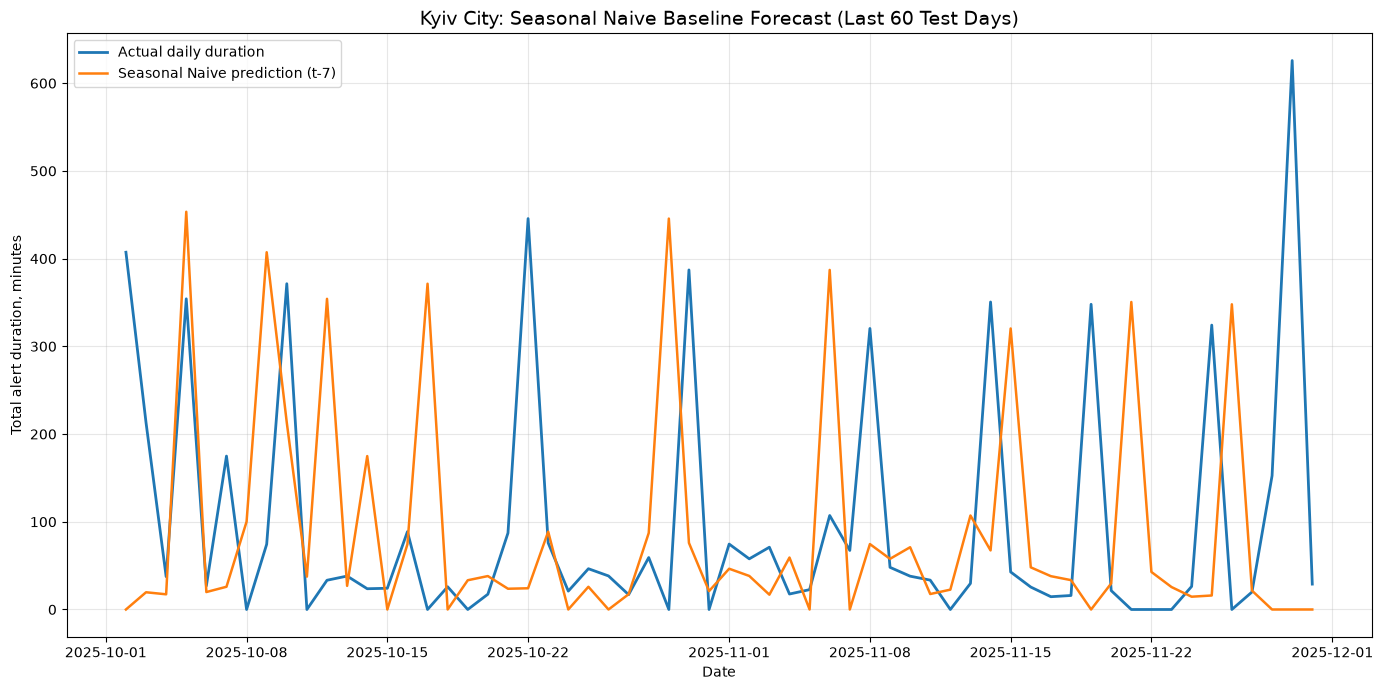

SEASONAL NAIVE BASELINE RESULT
Test period: 2025-06-04 to 2025-11-30
Test observations: 180
Zero-duration days in test: 28

Forecast metrics:


,model,forecast_region,test_start_date,test_end_date,test_rows,mae_min,rmse_min,smape_percent,zero_duration_days_in_test
0,Seasonal Naive (lag 7),Kyiv City,2025-06-04,2025-11-30,180,134.345,198.484,124.905,28



First 10 baseline predictions:

First 10 baseline predictions:


,date,actual_duration_min,seasonal_naive_duration_min,absolute_error_min,squared_error_min2,smape_component
0,2025-06-04,28.73,82.12,53.38,2849.78,0.96
1,2025-06-05,21.03,0.00,21.03,442.40,2.00
2,2025-06-06,248.22,0.00,248.22,61611.51,2.00
3,2025-06-07,37.73,27.87,9.87,97.35,0.30
4,2025-06-08,74.25,641.03,566.78,321243.35,1.58
5,2025-06-09,362.48,47.43,315.05,99256.50,1.54
6,2025-06-10,359.95,85.02,274.93,75588.34,1.24
7,2025-06-11,12.68,28.73,16.05,257.60,0.78
8,2025-06-12,0.00,21.03,21.03,442.40,2.00
9,2025-06-13,0.00,248.22,248.22,61611.51,2.00



Files created:
  D:\it10\PythonProject2\reports\seasonal_naive_test_predictions.csv
  D:\it10\PythonProject2\reports\forecast_metrics.csv
  D:\it10\PythonProject2\reports\figures\06_kyiv_city_seasonal_naive_baseline.png

✅ Seasonal Naive baseline was evaluated successfully.


In [3]:
# =====================================================================
# Seasonal Naive baseline evaluation for Kyiv City
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import config

importlib.reload(config)

REPORTS_DIR = config.REPORTS_DIR
FORECAST_METRICS_FILE = config.FORECAST_METRICS_FILE
FORECAST_TEST_SIZE_DAYS = config.FORECAST_TEST_SIZE_DAYS


# ---------------------------------------------------------------------
# 1. Validate that the chronological test dataset is available
# ---------------------------------------------------------------------

required_test_columns = [
    "date",
    "target",
    "seasonal_naive_prediction",
]

if "test_data" not in globals():
    raise NameError(
        "test_data was not found in the notebook memory.\n"
        "Run the first forecasting-preparation cell first."
    )

missing_columns = [
    column
    for column in required_test_columns
    if column not in test_data.columns
]

if missing_columns:
    raise KeyError(
        "test_data is missing required columns:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n{test_data.columns.tolist()}"
    )

if len(test_data) != FORECAST_TEST_SIZE_DAYS:
    raise ValueError(
        "Unexpected number of test rows.\n"
        f"Expected: {FORECAST_TEST_SIZE_DAYS}\n"
        f"Received: {len(test_data)}"
    )


# ---------------------------------------------------------------------
# 2. Prepare actual values and Seasonal Naive predictions
# ---------------------------------------------------------------------

baseline_evaluation = (
    test_data[
        [
            "date",
            "target",
            "seasonal_naive_prediction",
        ]
    ]
    .copy()
    .rename(
        columns={
            "target": "actual_duration_min",
            "seasonal_naive_prediction": (
                "seasonal_naive_duration_min"
            ),
        }
    )
    .sort_values("date")
    .reset_index(drop=True)
)

prediction_columns = [
    "actual_duration_min",
    "seasonal_naive_duration_min",
]

if baseline_evaluation[prediction_columns].isna().any().any():
    raise ValueError(
        "Missing actual values or Seasonal Naive predictions "
        "were found in the test dataset."
    )

if not np.isfinite(
    baseline_evaluation[prediction_columns].to_numpy()
).all():
    raise ValueError(
        "Non-finite values were found in the baseline evaluation data."
    )

if (baseline_evaluation[prediction_columns] < 0).any().any():
    raise ValueError(
        "Negative durations were found in the baseline evaluation data."
    )


# ---------------------------------------------------------------------
# 3. Calculate forecast errors and metrics
# ---------------------------------------------------------------------

baseline_evaluation["absolute_error_min"] = (
    baseline_evaluation["actual_duration_min"]
    - baseline_evaluation["seasonal_naive_duration_min"]
).abs()

baseline_evaluation["squared_error_min2"] = (
    baseline_evaluation["actual_duration_min"]
    - baseline_evaluation["seasonal_naive_duration_min"]
) ** 2

smape_denominator = (
    baseline_evaluation["actual_duration_min"].abs()
    + baseline_evaluation["seasonal_naive_duration_min"].abs()
)

baseline_evaluation["smape_component"] = np.where(
    smape_denominator.eq(0),
    0.0,
    (
        2
        * baseline_evaluation["absolute_error_min"]
        / smape_denominator
    ),
)

mae = baseline_evaluation["absolute_error_min"].mean()

rmse = np.sqrt(
    baseline_evaluation["squared_error_min2"].mean()
)

smape_percent = (
    baseline_evaluation["smape_component"].mean()
    * 100
)

zero_duration_days = int(
    baseline_evaluation["actual_duration_min"].eq(0).sum()
)

metrics_table = pd.DataFrame(
    [
        {
            "model": "Seasonal Naive (lag 7)",
            "forecast_region": config.FORECAST_REGION,
            "test_start_date": baseline_evaluation["date"].min().date(),
            "test_end_date": baseline_evaluation["date"].max().date(),
            "test_rows": len(baseline_evaluation),
            "mae_min": mae,
            "rmse_min": rmse,
            "smape_percent": smape_percent,
            "zero_duration_days_in_test": zero_duration_days,
        }
    ]
)


# ---------------------------------------------------------------------
# 4. Save baseline predictions and metrics
# ---------------------------------------------------------------------

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

baseline_predictions_path = (
    REPORTS_DIR
    / "seasonal_naive_test_predictions.csv"
)

baseline_evaluation.to_csv(
    baseline_predictions_path,
    index=False,
)

metrics_table.to_csv(
    FORECAST_METRICS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 5. Plot the final 60 days of the test period
# ---------------------------------------------------------------------

plot_days = 60

plot_data = baseline_evaluation.tail(plot_days)

baseline_figure_path = (
    config.FIGURES_DIR
    / "06_kyiv_city_seasonal_naive_baseline.png"
)

config.FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure, axes = plt.subplots(
    figsize=(14, 7),
)

axes.plot(
    plot_data["date"],
    plot_data["actual_duration_min"],
    label="Actual daily duration",
    linewidth=2,
)

axes.plot(
    plot_data["date"],
    plot_data["seasonal_naive_duration_min"],
    label="Seasonal Naive prediction (t-7)",
    linewidth=1.8,
)

axes.set_title(
    "Kyiv City: Seasonal Naive Baseline Forecast "
    "(Last 60 Test Days)",
    fontsize=14,
)

axes.set_xlabel("Date")
axes.set_ylabel("Total alert duration, minutes")

axes.grid(
    True,
    alpha=0.3,
)

axes.legend()

figure.tight_layout()

figure.savefig(
    baseline_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# 6. Output and checks
# ---------------------------------------------------------------------

print("=" * 78)
print("SEASONAL NAIVE BASELINE RESULT")
print("=" * 78)

print(
    f"Test period: "
    f"{baseline_evaluation['date'].min().date()} "
    f"to {baseline_evaluation['date'].max().date()}"
)

print(f"Test observations: {len(baseline_evaluation):,}")
print(f"Zero-duration days in test: {zero_duration_days:,}")

print("\nForecast metrics:")
metrics_preview = metrics_table.copy()

numeric_columns = metrics_preview.select_dtypes(
    include="number"
).columns

metrics_preview[numeric_columns] = (
    metrics_preview[numeric_columns]
    .round(3)
)

display(metrics_preview)

print("\nFirst 10 baseline predictions:")
print("\nFirst 10 baseline predictions:")

baseline_preview = baseline_evaluation.head(10).copy()

numeric_columns = baseline_preview.select_dtypes(
    include="number"
).columns

baseline_preview[numeric_columns] = (
    baseline_preview[numeric_columns]
    .round(2)
)

display(baseline_preview)

assert len(baseline_evaluation) == FORECAST_TEST_SIZE_DAYS
assert baseline_evaluation["date"].is_monotonic_increasing
assert baseline_evaluation["absolute_error_min"].ge(0).all()
assert baseline_predictions_path.exists()
assert FORECAST_METRICS_FILE.exists()
assert baseline_figure_path.exists()

print("\nFiles created:")
print(f"  {baseline_predictions_path}")
print(f"  {FORECAST_METRICS_FILE}")
print(f"  {baseline_figure_path}")

print("\n✅ Seasonal Naive baseline was evaluated successfully.")

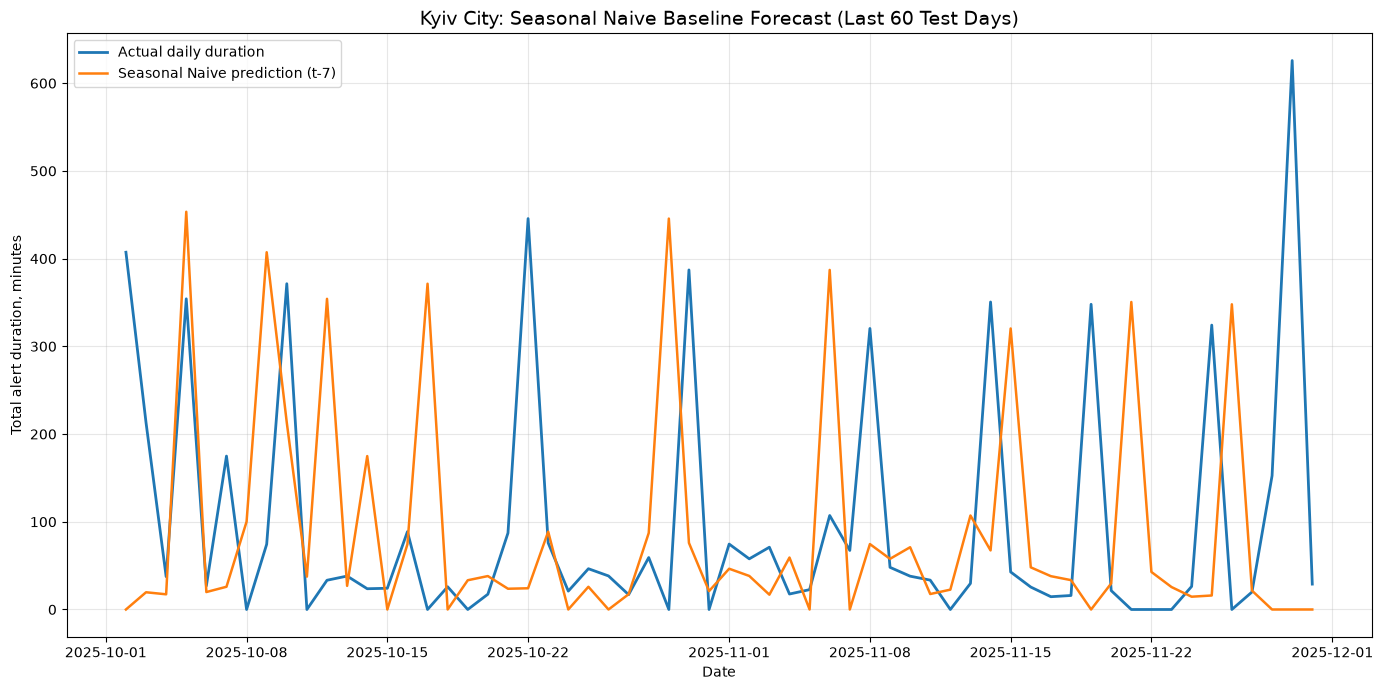

REUSABLE SEASONAL NAIVE BASELINE RESULT


,model,forecast_region,test_start_date,test_end_date,test_rows,mae_min,rmse_min,smape_percent,zero_duration_days_in_test
0,Seasonal Naive (lag 7),Kyiv City,2025-06-04,2025-11-30,180,134.345,198.484,124.905,28



Files created:
  D:\it10\PythonProject2\reports\seasonal_naive_test_predictions.csv
  D:\it10\PythonProject2\reports\forecast_metrics.csv
  D:\it10\PythonProject2\reports\figures\06_kyiv_city_seasonal_naive_baseline.png

✅ Reusable Seasonal Naive baseline works correctly.


In [4]:
# =====================================================================
# Reusable Seasonal Naive baseline evaluation
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import config
import forecasting

importlib.reload(config)
importlib.reload(forecasting)

from forecasting import (
    evaluate_seasonal_naive_baseline,
    plot_seasonal_naive_baseline,
)


# ---------------------------------------------------------------------
# Load stored test data
# ---------------------------------------------------------------------

FORECAST_TEST_FILE = config.FORECAST_TEST_FILE
FORECAST_METRICS_FILE = config.FORECAST_METRICS_FILE
FORECAST_REGION = config.FORECAST_REGION
REPORTS_DIR = config.REPORTS_DIR
FIGURES_DIR = config.FIGURES_DIR

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

test_data_script = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)


# ---------------------------------------------------------------------
# Evaluate baseline with reusable script
# ---------------------------------------------------------------------

baseline_evaluation_script, baseline_metrics_script = (
    evaluate_seasonal_naive_baseline(
        test_data=test_data_script,
        forecast_region=FORECAST_REGION,
    )
)

baseline_predictions_path = (
    REPORTS_DIR
    / "seasonal_naive_test_predictions.csv"
)

baseline_figure_path = (
    FIGURES_DIR
    / "06_kyiv_city_seasonal_naive_baseline.png"
)

baseline_evaluation_script.to_csv(
    baseline_predictions_path,
    index=False,
)

baseline_metrics_script.to_csv(
    FORECAST_METRICS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# Create reusable comparison plot
# ---------------------------------------------------------------------

figure, axes = plot_seasonal_naive_baseline(
    baseline_evaluation=baseline_evaluation_script,
    output_path=baseline_figure_path,
    plot_days=60,
)

plt.show()


# ---------------------------------------------------------------------
# Output and validation
# ---------------------------------------------------------------------

print("=" * 78)
print("REUSABLE SEASONAL NAIVE BASELINE RESULT")
print("=" * 78)

metrics_preview = baseline_metrics_script.copy()

numeric_columns = metrics_preview.select_dtypes(
    include="number"
).columns

metrics_preview[numeric_columns] = (
    metrics_preview[numeric_columns]
    .round(3)
)

display(metrics_preview)

assert len(baseline_evaluation_script) == 180
assert baseline_predictions_path.exists()
assert FORECAST_METRICS_FILE.exists()
assert baseline_figure_path.exists()

print("\nFiles created:")
print(f"  {baseline_predictions_path}")
print(f"  {FORECAST_METRICS_FILE}")
print(f"  {baseline_figure_path}")

print("\n✅ Reusable Seasonal Naive baseline works correctly.")

RIDGE REGRESSION DATA CHECK
Forecast region: Kyiv City
Training rows: 1,149
Test rows: 180
Number of model features: 13
Training range: 2022-04-12 to 2025-06-03
Test range: 2025-06-04 to 2025-11-30

Model features:
  - lag_1
  - lag_7
  - lag_14
  - rolling_mean_7
  - rolling_mean_14
  - rolling_mean_28
  - day_of_week
  - is_weekend
  - month
  - day_of_week_sin
  - day_of_week_cos
  - month_sin
  - month_cos

RIDGE TIME-SERIES VALIDATION
Validation splits: 5
Best alpha: 1000.0
Best mean validation MAE: 79.700 minutes


,alpha,mean_validation_mae_min,validation_mae_std_min,mean_training_mae_min
0,1000.00,79.700,11.549,72.346
1,100.00,80.647,13.798,70.885
2,10.00,83.238,16.964,70.401
3,1.00,89.745,27.395,70.146
4,0.10,99.667,45.909,70.070
5,0.01,101.300,49.055,70.063


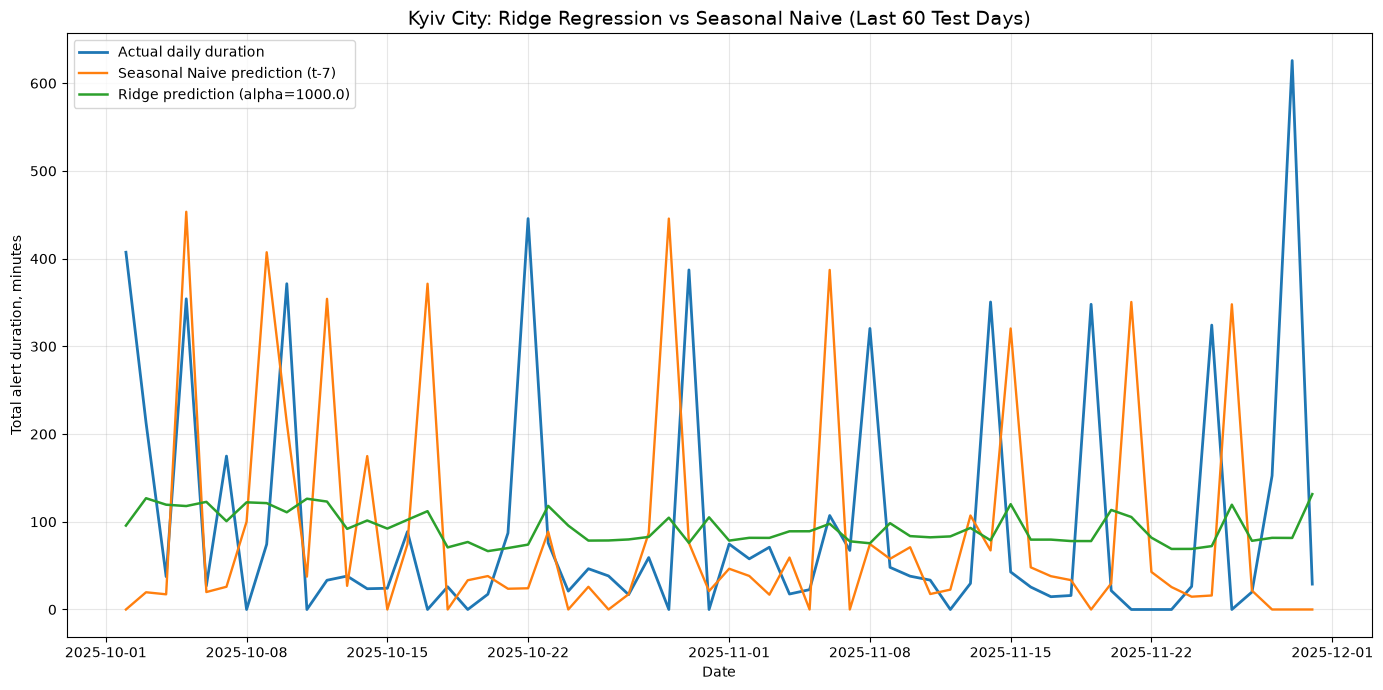


RIDGE REGRESSION TEST RESULT


,model,forecast_region,test_start_date,test_end_date,test_rows,mae_min,rmse_min,smape_percent,zero_duration_days_in_test,negative_raw_predictions_clipped_to_zero
0,Ridge Regression (alpha=1000.0),Kyiv City,2025-06-04,2025-11-30,180,111.104,150.887,106.666,28,0
1,Seasonal Naive (lag 7),Kyiv City,2025-06-04,2025-11-30,180,134.345,198.484,124.905,28,0



Most influential standardized Ridge coefficients:


,feature,standardized_coefficient,absolute_coefficient
0,rolling_mean_14,9.4779,9.4779
1,rolling_mean_7,8.6143,8.6143
2,rolling_mean_28,7.4105,7.4105
3,lag_1,6.9497,6.9497
4,lag_7,5.2464,5.2464
5,month_cos,2.0987,2.0987
6,lag_14,2.0252,2.0252
7,day_of_week_cos,-1.7152,1.7152
8,is_weekend,-0.9295,0.9295
9,month_sin,0.8642,0.8642



Raw negative Ridge predictions clipped to zero: 0

Files created:
  D:\it10\PythonProject2\reports\ridge_test_predictions.csv
  D:\it10\PythonProject2\reports\ridge_feature_coefficients.csv
  D:\it10\PythonProject2\reports\forecast_metrics.csv
  D:\it10\PythonProject2\reports\figures\07_kyiv_city_ridge_vs_baseline.png

✅ Ridge Regression was trained and compared with Seasonal Naive successfully.


In [6]:
# =====================================================================
# Ridge Regression forecast:
# training, time-series validation and comparison with baseline
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import config
import forecasting

importlib.reload(config)
importlib.reload(forecasting)

from forecasting import (
    calculate_forecast_metrics,
    evaluate_seasonal_naive_baseline,
)


# ---------------------------------------------------------------------
# 1. Load configuration and stored chronological datasets
# ---------------------------------------------------------------------

FORECAST_TRAIN_FILE = config.FORECAST_TRAIN_FILE
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE

FORECAST_METRICS_FILE = config.FORECAST_METRICS_FILE
RIDGE_TEST_PREDICTIONS_FILE = config.RIDGE_TEST_PREDICTIONS_FILE
RIDGE_FEATURE_COEFFICIENTS_FILE = config.RIDGE_FEATURE_COEFFICIENTS_FILE

FORECAST_REGION = config.FORECAST_REGION
FORECAST_LAGS = config.FORECAST_LAGS
FORECAST_ROLLING_WINDOWS = config.FORECAST_ROLLING_WINDOWS
FORECAST_TEST_SIZE_DAYS = config.FORECAST_TEST_SIZE_DAYS

RIDGE_ALPHA_CANDIDATES = config.RIDGE_ALPHA_CANDIDATES
RIDGE_TIME_SERIES_SPLITS = config.RIDGE_TIME_SERIES_SPLITS

REPORTS_DIR = config.REPORTS_DIR
FIGURES_DIR = config.FIGURES_DIR

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not FORECAST_TRAIN_FILE.exists():
    raise FileNotFoundError(
        "Training forecast dataset was not found.\n"
        f"Expected file: {FORECAST_TRAIN_FILE}"
    )

if not FORECAST_TEST_FILE.exists():
    raise FileNotFoundError(
        "Test forecast dataset was not found.\n"
        f"Expected file: {FORECAST_TEST_FILE}"
    )

train_data_ridge = pd.read_csv(
    FORECAST_TRAIN_FILE,
    parse_dates=["date"],
)

test_data_ridge = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)


# ---------------------------------------------------------------------
# 2. Reconstruct the exact 13 model features
# ---------------------------------------------------------------------

feature_columns = [
    *[
        f"lag_{lag}"
        for lag in FORECAST_LAGS
    ],
    *[
        f"rolling_mean_{window}"
        for window in FORECAST_ROLLING_WINDOWS
    ],
    "day_of_week",
    "is_weekend",
    "month",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
]

required_columns = [
    "date",
    "target",
    "seasonal_naive_prediction",
    *feature_columns,
]

missing_train_columns = [
    column
    for column in required_columns
    if column not in train_data_ridge.columns
]

missing_test_columns = [
    column
    for column in required_columns
    if column not in test_data_ridge.columns
]

if missing_train_columns:
    raise KeyError(
        "Training data is missing required columns:\n"
        f"{missing_train_columns}"
    )

if missing_test_columns:
    raise KeyError(
        "Test data is missing required columns:\n"
        f"{missing_test_columns}"
    )

if len(test_data_ridge) != FORECAST_TEST_SIZE_DAYS:
    raise ValueError(
        "Unexpected number of test rows.\n"
        f"Expected: {FORECAST_TEST_SIZE_DAYS}\n"
        f"Received: {len(test_data_ridge)}"
    )

if train_data_ridge["date"].max() >= test_data_ridge["date"].min():
    raise ValueError(
        "Training and test periods overlap."
    )

numeric_columns = [
    "target",
    *feature_columns,
]

for dataframe_name, dataframe in [
    ("train_data_ridge", train_data_ridge),
    ("test_data_ridge", test_data_ridge),
]:
    if dataframe[numeric_columns].isna().any().any():
        raise ValueError(
            f"{dataframe_name} contains missing values "
            "in target or feature columns."
        )

    if not np.isfinite(
        dataframe[numeric_columns].to_numpy()
    ).all():
        raise ValueError(
            f"{dataframe_name} contains non-finite values."
        )

print("=" * 78)
print("RIDGE REGRESSION DATA CHECK")
print("=" * 78)

print(f"Forecast region: {FORECAST_REGION}")
print(f"Training rows: {len(train_data_ridge):,}")
print(f"Test rows: {len(test_data_ridge):,}")
print(f"Number of model features: {len(feature_columns)}")

print(
    f"Training range: "
    f"{train_data_ridge['date'].min().date()} "
    f"to {train_data_ridge['date'].max().date()}"
)

print(
    f"Test range: "
    f"{test_data_ridge['date'].min().date()} "
    f"to {test_data_ridge['date'].max().date()}"
)

print("\nModel features:")
for feature_name in feature_columns:
    print(f"  - {feature_name}")


# ---------------------------------------------------------------------
# 3. Prepare train and test matrices
# ---------------------------------------------------------------------

X_train = train_data_ridge[feature_columns].copy()
y_train = train_data_ridge["target"].copy()

X_test = test_data_ridge[feature_columns].copy()
y_test = test_data_ridge["target"].copy()


# ---------------------------------------------------------------------
# 4. Select Ridge alpha using chronological validation splits
# ---------------------------------------------------------------------

time_series_cv = TimeSeriesSplit(
    n_splits=RIDGE_TIME_SERIES_SPLITS,
)

ridge_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "ridge",
            Ridge(),
        ),
    ]
)

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={
        "ridge__alpha": RIDGE_ALPHA_CANDIDATES,
    },
    scoring="neg_mean_absolute_error",
    cv=time_series_cv,
    refit=True,
    return_train_score=True,
)

ridge_search.fit(
    X_train,
    y_train,
)

best_ridge_model = ridge_search.best_estimator_
best_alpha = ridge_search.best_params_["ridge__alpha"]
best_validation_mae = -ridge_search.best_score_

cv_results = (
    pd.DataFrame(ridge_search.cv_results_)
    .loc[
        :,
        [
            "param_ridge__alpha",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
        ],
    ]
    .copy()
)

cv_results = cv_results.rename(
    columns={
        "param_ridge__alpha": "alpha",
        "mean_test_score": "mean_validation_mae_negative",
        "std_test_score": "validation_mae_std_negative",
        "mean_train_score": "mean_training_mae_negative",
    }
)

cv_results["mean_validation_mae_min"] = (
    -cv_results["mean_validation_mae_negative"]
)

cv_results["validation_mae_std_min"] = (
    cv_results["validation_mae_std_negative"].abs()
)

cv_results["mean_training_mae_min"] = (
    -cv_results["mean_training_mae_negative"]
)

cv_results = (
    cv_results
    .sort_values("mean_validation_mae_min")
    .reset_index(drop=True)
)

print("\n" + "=" * 78)
print("RIDGE TIME-SERIES VALIDATION")
print("=" * 78)

print(f"Validation splits: {RIDGE_TIME_SERIES_SPLITS}")
print(f"Best alpha: {best_alpha}")
print(
    f"Best mean validation MAE: "
    f"{best_validation_mae:.3f} minutes"
)

display(
    cv_results[
        [
            "alpha",
            "mean_validation_mae_min",
            "validation_mae_std_min",
            "mean_training_mae_min",
        ]
    ].round(3)
)


# ---------------------------------------------------------------------
# 5. Make Ridge predictions for the same 180 test days
# ---------------------------------------------------------------------

ridge_raw_predictions = best_ridge_model.predict(
    X_test
)

# Duration cannot be negative. This post-processing changes only
# impossible negative predictions to zero.
ridge_predictions = np.clip(
    ridge_raw_predictions,
    a_min=0,
    a_max=None,
)

ridge_evaluation = pd.DataFrame(
    {
        "date": test_data_ridge["date"].to_numpy(),
        "actual_duration_min": y_test.to_numpy(),
        "ridge_raw_prediction_min": ridge_raw_predictions,
        "ridge_duration_min": ridge_predictions,
    }
)

ridge_evaluation["absolute_error_min"] = (
    ridge_evaluation["actual_duration_min"]
    - ridge_evaluation["ridge_duration_min"]
).abs()

ridge_evaluation["squared_error_min2"] = (
    ridge_evaluation["actual_duration_min"]
    - ridge_evaluation["ridge_duration_min"]
) ** 2

smape_denominator = (
    ridge_evaluation["actual_duration_min"].abs()
    + ridge_evaluation["ridge_duration_min"].abs()
)

ridge_evaluation["smape_component"] = np.where(
    smape_denominator.eq(0),
    0.0,
    2
    * ridge_evaluation["absolute_error_min"]
    / smape_denominator,
)

ridge_metrics = calculate_forecast_metrics(
    actual_values=ridge_evaluation["actual_duration_min"],
    predicted_values=ridge_evaluation["ridge_duration_min"],
)

negative_raw_prediction_count = int(
    (ridge_evaluation["ridge_raw_prediction_min"] < 0).sum()
)

ridge_metrics_table = pd.DataFrame(
    [
        {
            "model": (
                f"Ridge Regression "
                f"(alpha={best_alpha})"
            ),
            "forecast_region": FORECAST_REGION,
            "test_start_date": ridge_evaluation["date"].min().date(),
            "test_end_date": ridge_evaluation["date"].max().date(),
            "test_rows": len(ridge_evaluation),
            "mae_min": ridge_metrics["mae_min"],
            "rmse_min": ridge_metrics["rmse_min"],
            "smape_percent": ridge_metrics["smape_percent"],
            "zero_duration_days_in_test": int(
                ridge_evaluation["actual_duration_min"]
                .eq(0)
                .sum()
            ),
            "negative_raw_predictions_clipped_to_zero": (
                negative_raw_prediction_count
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# 6. Recalculate baseline on the same stored test data
# ---------------------------------------------------------------------

baseline_evaluation_ridge, baseline_metrics_ridge = (
    evaluate_seasonal_naive_baseline(
        test_data=test_data_ridge,
        forecast_region=FORECAST_REGION,
    )
)

baseline_metrics_ridge[
    "negative_raw_predictions_clipped_to_zero"
] = 0

comparison_metrics = pd.concat(
    [
        baseline_metrics_ridge,
        ridge_metrics_table,
    ],
    ignore_index=True,
)

comparison_metrics = comparison_metrics.sort_values(
    by="mae_min",
    ascending=True,
).reset_index(drop=True)


# ---------------------------------------------------------------------
# 7. Prepare standardized Ridge coefficient table
# ---------------------------------------------------------------------

ridge_coefficients = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "standardized_coefficient": (
                best_ridge_model
                .named_steps["ridge"]
                .coef_
            ),
        }
    )
)

ridge_coefficients["absolute_coefficient"] = (
    ridge_coefficients["standardized_coefficient"]
    .abs()
)

ridge_coefficients = (
    ridge_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# 8. Save predictions, model comparison and coefficients
# ---------------------------------------------------------------------

baseline_predictions_path = (
    REPORTS_DIR
    / "seasonal_naive_test_predictions.csv"
)

comparison_figure_path = (
    FIGURES_DIR
    / "07_kyiv_city_ridge_vs_baseline.png"
)

ridge_evaluation.to_csv(
    RIDGE_TEST_PREDICTIONS_FILE,
    index=False,
)

baseline_evaluation_ridge.to_csv(
    baseline_predictions_path,
    index=False,
)

comparison_metrics.to_csv(
    FORECAST_METRICS_FILE,
    index=False,
)

ridge_coefficients.to_csv(
    RIDGE_FEATURE_COEFFICIENTS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 9. Plot actual values, baseline and Ridge predictions
# ---------------------------------------------------------------------

plot_days = 60

comparison_plot_data = (
    ridge_evaluation
    .tail(plot_days)
    .merge(
        baseline_evaluation_ridge[
            [
                "date",
                "seasonal_naive_duration_min",
            ]
        ],
        on="date",
        how="left",
        validate="one_to_one",
    )
)

if comparison_plot_data[
    "seasonal_naive_duration_min"
].isna().any():
    raise ValueError(
        "Baseline predictions could not be aligned "
        "with Ridge test dates."
    )

figure, axes = plt.subplots(
    figsize=(14, 7),
)

axes.plot(
    comparison_plot_data["date"],
    comparison_plot_data["actual_duration_min"],
    label="Actual daily duration",
    linewidth=2,
)

axes.plot(
    comparison_plot_data["date"],
    comparison_plot_data["seasonal_naive_duration_min"],
    label="Seasonal Naive prediction (t-7)",
    linewidth=1.7,
)

axes.plot(
    comparison_plot_data["date"],
    comparison_plot_data["ridge_duration_min"],
    label=f"Ridge prediction (alpha={best_alpha})",
    linewidth=1.8,
)

axes.set_title(
    "Kyiv City: Ridge Regression vs Seasonal Naive "
    f"(Last {plot_days} Test Days)",
    fontsize=14,
)

axes.set_xlabel("Date")
axes.set_ylabel("Total alert duration, minutes")

axes.grid(
    True,
    alpha=0.3,
)

axes.legend()

figure.tight_layout()

figure.savefig(
    comparison_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# 10. Output and final checks
# ---------------------------------------------------------------------

print("\n" + "=" * 78)
print("RIDGE REGRESSION TEST RESULT")
print("=" * 78)

metrics_preview = comparison_metrics.copy()

numeric_columns = metrics_preview.select_dtypes(
    include="number"
).columns

metrics_preview[numeric_columns] = (
    metrics_preview[numeric_columns]
    .round(3)
)

display(metrics_preview)

print("\nMost influential standardized Ridge coefficients:")
display(
    ridge_coefficients
    .head(10)
    .round(4)
)

print(
    f"\nRaw negative Ridge predictions clipped to zero: "
    f"{negative_raw_prediction_count}"
)

assert len(ridge_evaluation) == FORECAST_TEST_SIZE_DAYS

assert ridge_evaluation["date"].equals(
    baseline_evaluation_ridge["date"]
)

assert (
    ridge_evaluation["ridge_duration_min"] >= 0
).all()

assert set(comparison_metrics["model"]) == {
    "Seasonal Naive (lag 7)",
    f"Ridge Regression (alpha={best_alpha})",
}

assert RIDGE_TEST_PREDICTIONS_FILE.exists()
assert RIDGE_FEATURE_COEFFICIENTS_FILE.exists()
assert FORECAST_METRICS_FILE.exists()
assert comparison_figure_path.exists()

print("\nFiles created:")
print(f"  {RIDGE_TEST_PREDICTIONS_FILE}")
print(f"  {RIDGE_FEATURE_COEFFICIENTS_FILE}")
print(f"  {FORECAST_METRICS_FILE}")
print(f"  {comparison_figure_path}")

print(
    "\n✅ Ridge Regression was trained and compared "
    "with Seasonal Naive successfully."
)

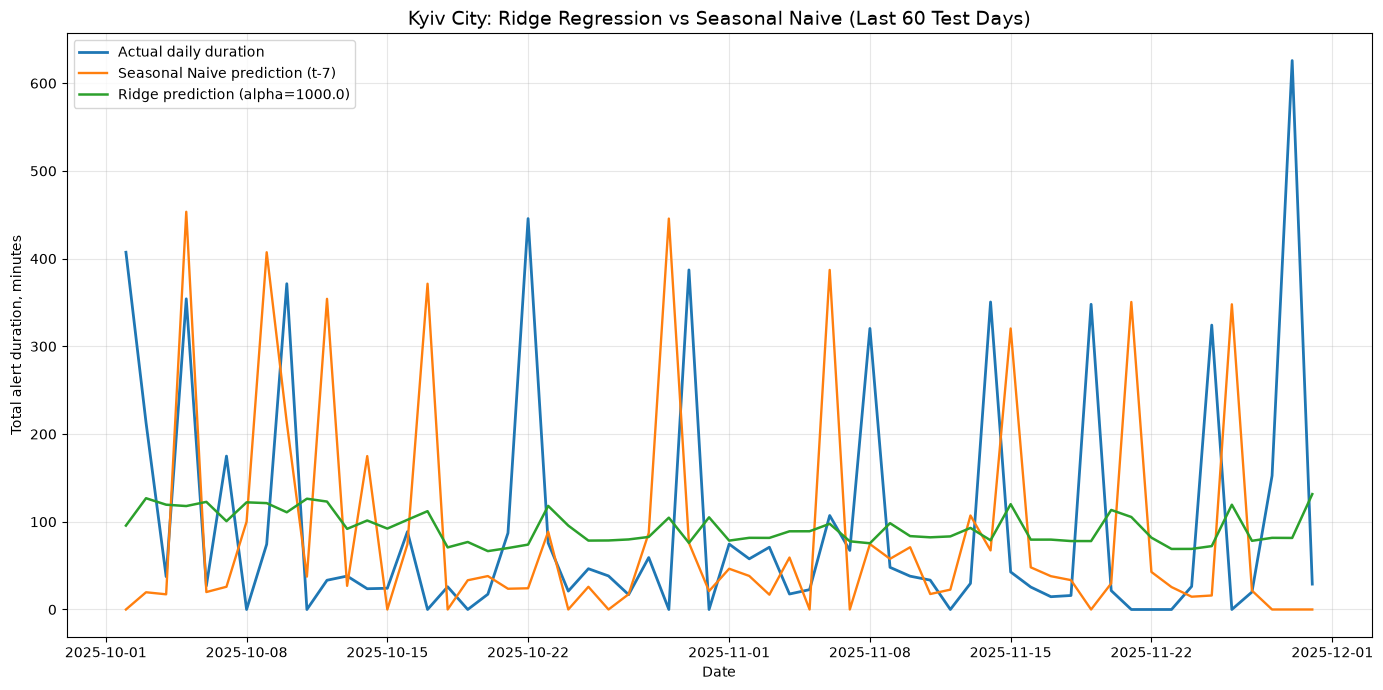

REUSABLE RIDGE REGRESSION RESULT
Best alpha: 1000.0

Ridge time-series validation:


,alpha,mean_validation_mae_min,validation_mae_std_min,mean_training_mae_min
0,1000.00,79.700,11.549,72.346
1,100.00,80.647,13.798,70.885
2,10.00,83.238,16.964,70.401
3,1.00,89.745,27.395,70.146
4,0.10,99.667,45.909,70.070
5,0.01,101.300,49.055,70.063



Final test comparison:


,model,forecast_region,test_start_date,test_end_date,test_rows,mae_min,rmse_min,smape_percent,zero_duration_days_in_test,negative_raw_predictions_clipped_to_zero
0,Ridge Regression (alpha=1000.0),Kyiv City,2025-06-04,2025-11-30,180,111.104,150.887,106.666,28,0
1,Seasonal Naive (lag 7),Kyiv City,2025-06-04,2025-11-30,180,134.345,198.484,124.905,28,0



Most influential standardized Ridge coefficients:


,feature,standardized_coefficient,absolute_coefficient
0,rolling_mean_14,9.4779,9.4779
1,rolling_mean_7,8.6143,8.6143
2,rolling_mean_28,7.4105,7.4105
3,lag_1,6.9497,6.9497
4,lag_7,5.2464,5.2464
5,month_cos,2.0987,2.0987
6,lag_14,2.0252,2.0252
7,day_of_week_cos,-1.7152,1.7152
8,is_weekend,-0.9295,0.9295
9,month_sin,0.8642,0.8642



Files created:
  D:\it10\PythonProject2\reports\ridge_test_predictions.csv
  D:\it10\PythonProject2\reports\ridge_feature_coefficients.csv
  D:\it10\PythonProject2\reports\forecast_metrics.csv
  D:\it10\PythonProject2\reports\figures\07_kyiv_city_ridge_vs_baseline.png

✅ Reusable Ridge Regression training and comparison work correctly.


In [7]:
# =====================================================================
# Reusable Ridge Regression training and comparison with baseline
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import config
import forecasting

importlib.reload(config)
importlib.reload(forecasting)

from forecasting import (
    evaluate_seasonal_naive_baseline,
    plot_ridge_vs_baseline,
    train_and_evaluate_ridge_regression,
)


# ---------------------------------------------------------------------
# 1. Load configuration and stored chronological datasets
# ---------------------------------------------------------------------

FORECAST_TRAIN_FILE = config.FORECAST_TRAIN_FILE
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE

FORECAST_METRICS_FILE = config.FORECAST_METRICS_FILE
RIDGE_TEST_PREDICTIONS_FILE = config.RIDGE_TEST_PREDICTIONS_FILE
RIDGE_FEATURE_COEFFICIENTS_FILE = (
    config.RIDGE_FEATURE_COEFFICIENTS_FILE
)

FORECAST_REGION = config.FORECAST_REGION
FORECAST_LAGS = config.FORECAST_LAGS
FORECAST_ROLLING_WINDOWS = config.FORECAST_ROLLING_WINDOWS

RIDGE_ALPHA_CANDIDATES = config.RIDGE_ALPHA_CANDIDATES
RIDGE_TIME_SERIES_SPLITS = config.RIDGE_TIME_SERIES_SPLITS

REPORTS_DIR = config.REPORTS_DIR
FIGURES_DIR = config.FIGURES_DIR

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

train_data_script = pd.read_csv(
    FORECAST_TRAIN_FILE,
    parse_dates=["date"],
)

test_data_script = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)


# ---------------------------------------------------------------------
# 2. Rebuild the 13 model-feature names
# ---------------------------------------------------------------------

feature_columns = [
    *[
        f"lag_{lag}"
        for lag in FORECAST_LAGS
    ],
    *[
        f"rolling_mean_{window}"
        for window in FORECAST_ROLLING_WINDOWS
    ],
    "day_of_week",
    "is_weekend",
    "month",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
]


# ---------------------------------------------------------------------
# 3. Evaluate Seasonal Naive and train Ridge
# ---------------------------------------------------------------------

baseline_evaluation_script, baseline_metrics_script = (
    evaluate_seasonal_naive_baseline(
        test_data=test_data_script,
        forecast_region=FORECAST_REGION,
    )
)

(
    ridge_evaluation_script,
    ridge_metrics_script,
    ridge_coefficients_script,
    ridge_cv_results_script,
    best_ridge_model_script,
) = train_and_evaluate_ridge_regression(
    train_data=train_data_script,
    test_data=test_data_script,
    feature_columns=feature_columns,
    forecast_region=FORECAST_REGION,
    alpha_candidates=RIDGE_ALPHA_CANDIDATES,
    time_series_splits=RIDGE_TIME_SERIES_SPLITS,
)

best_alpha = float(
    best_ridge_model_script
    .named_steps["ridge"]
    .alpha
)

baseline_metrics_script[
    "negative_raw_predictions_clipped_to_zero"
] = 0

comparison_metrics_script = pd.concat(
    [
        baseline_metrics_script,
        ridge_metrics_script,
    ],
    ignore_index=True,
)

comparison_metrics_script = (
    comparison_metrics_script
    .sort_values(
        "mae_min",
        ascending=True,
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# 4. Save reusable results
# ---------------------------------------------------------------------

baseline_predictions_path = (
    REPORTS_DIR
    / "seasonal_naive_test_predictions.csv"
)

comparison_figure_path = (
    FIGURES_DIR
    / "07_kyiv_city_ridge_vs_baseline.png"
)

baseline_evaluation_script.to_csv(
    baseline_predictions_path,
    index=False,
)

ridge_evaluation_script.to_csv(
    RIDGE_TEST_PREDICTIONS_FILE,
    index=False,
)

ridge_coefficients_script.to_csv(
    RIDGE_FEATURE_COEFFICIENTS_FILE,
    index=False,
)

comparison_metrics_script.to_csv(
    FORECAST_METRICS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 5. Create the comparison figure
# ---------------------------------------------------------------------

figure, axes = plot_ridge_vs_baseline(
    ridge_evaluation=ridge_evaluation_script,
    baseline_evaluation=baseline_evaluation_script,
    best_alpha=best_alpha,
    output_path=comparison_figure_path,
    plot_days=60,
)

plt.show()


# ---------------------------------------------------------------------
# 6. Display results and validate
# ---------------------------------------------------------------------

print("=" * 78)
print("REUSABLE RIDGE REGRESSION RESULT")
print("=" * 78)

print(f"Best alpha: {best_alpha}")

print("\nRidge time-series validation:")
display(
    ridge_cv_results_script[
        [
            "alpha",
            "mean_validation_mae_min",
            "validation_mae_std_min",
            "mean_training_mae_min",
        ]
    ].round(3)
)

print("\nFinal test comparison:")
display(
    comparison_metrics_script.round(3)
)

print("\nMost influential standardized Ridge coefficients:")
display(
    ridge_coefficients_script
    .head(10)
    .round(4)
)

assert len(ridge_evaluation_script) == 180
assert (
    ridge_evaluation_script["ridge_duration_min"] >= 0
).all()

assert len(comparison_metrics_script) == 2
assert comparison_figure_path.exists()
assert RIDGE_TEST_PREDICTIONS_FILE.exists()
assert RIDGE_FEATURE_COEFFICIENTS_FILE.exists()
assert FORECAST_METRICS_FILE.exists()

print("\nFiles created:")
print(f"  {RIDGE_TEST_PREDICTIONS_FILE}")
print(f"  {RIDGE_FEATURE_COEFFICIENTS_FILE}")
print(f"  {FORECAST_METRICS_FILE}")
print(f"  {comparison_figure_path}")

print(
    "\n✅ Reusable Ridge Regression training and comparison "
    "work correctly."
)